Correlation and Rule Evaluation for Phishing Discovery: A Comparative Study of Interestingness Measures

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import numpy as np
import time
from scipy.stats import chi2_contingency

data, meta = arff.loadarff('Training Dataset.arff')
df = pd.DataFrame(data)

for col in df.columns:
    df[col] = df[col].str.decode('utf-8').astype(int)

mapping={
    "having_IP_Address":  { -1: 'has_IP',1: 'no_IP' },
    "URL_Length":   { 1:'short_URL',0:'medium_URL',-1:'long_URL' },
    "Shortining_Service": { 1:'No_Shortining',-1:'Has_Shortining' },
    "having_At_Symbol":   { 1:'no_@_symbol',-1:'has_@_symbol' },
    "double_slash_redirecting": { -1:'last_position_bigger_than_7',1:'last_position_less_than_7' },
    "Prefix_Suffix":  { -1:'Has_PrefixSuffix',1:'No_PrefixSuffix' },
    "having_Sub_Domain":  { -1:'Multi_SubDomain',0:'One_SubDomain',1:'No_SubDomain' },
    "SSLfinal_State":  { -1:'No_HTTPS',1:'HTTPS_Trusted',0:'SSL_Suspicious' },
    "Domain_registeration_length":{ -1:'Domain_ShortTerm',1:'Domain_LongTerm' },
    "Favicon" :{ 1: 'Favicon_Internal',-1: 'Favicon_External' },
    "port" :{ 1:'Port_Standard',-1:'Port_NonStandard' },
    "HTTPS_token": { -1: 'Has_HTTPS_Token_In_Domain',1: 'No_HTTPS_Token_In_Domain' },
    "Request_URL":  { 1:'ReqURL_LowExtContent',-1:'ReqURL_HighExtContent' },
    "URL_of_Anchor": { -1:'greater_than_%67_Anchor',0:'between_%31_%67_Anchor',1:'less_than_%31_Anchor' },
    "Links_in_tags": { 1:'less_than_%17',-1:'greater_than_%81',0:'between_%17_%81' },
    "SFH":  { -1:'Empty_or_Blank',1:'Same_Domain',0:'Diiferent_than_Domain' },
    "Submitting_to_email": { -1:'using_mail_func',1:'not_using_mail_func' },
    "Abnormal_URL": { -1:'no_hostname_in_URL',1:'hostname_in_URL' },
    "Redirect":  { 0: 'Redirect_between_2-4',1: 'Redirect_Less_Than_1' }, 
    "on_mouseover":  { 1:'onMouseOver_doesnt_Changes_Status_Bar',-1:'onMouseOver_Changes_Status_Bar' },
    "RightClick" : { 1:'Enabled',-1:'Disabled' },
    "popUpWidnow" : { 1: 'No_Popup_Text_Fields',-1: 'Has_Popup_Text_Fields' },
    "Iframe" :{ 1: 'No_IFrame',-1: 'Has_IFrame' },
    "age_of_domain" : { -1: 'Domain_Age_Less_6Month',1: 'Domain_Age_More_6Month' },
    "DNSRecord"  : { -1: 'No_DNS_Record',1: 'Has_DNS_Record' },
    "web_traffic" : { -1: 'Low_Traffic',0: 'Medium_Traffic',1: 'High_Traffic' },
    "Page_Rank": { -1: 'PageRank_Low',1: 'PageRank_High' },
    "Google_Index":{ 1:'Indexed by Google',-1:'Not Indexed by Google' },
    "Links_pointing_to_page": { 1:'at least 2 external links pointing ',0:'have 1 or 2 links pointing',-1:'have no links pointing' },
    "Statistical_report": { -1:'Belongs to Top Phishing IPs/Domains',1:'Dont Belong to Top Phishing IPs/Domains' },
    "Result" : { -1: 'Phishing',1: 'Legitimate' },
}

df_mapped = df.copy()
for col, counts in mapping.items():
    df_mapped[col] = df_mapped[col].map(counts)

#print(df_mapped.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

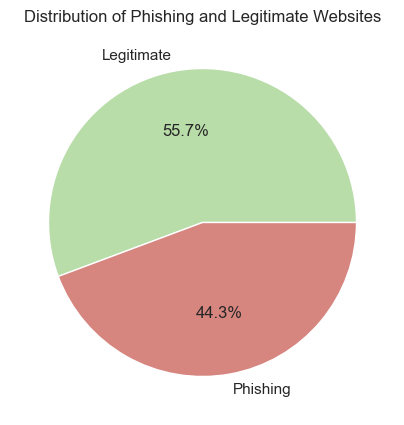

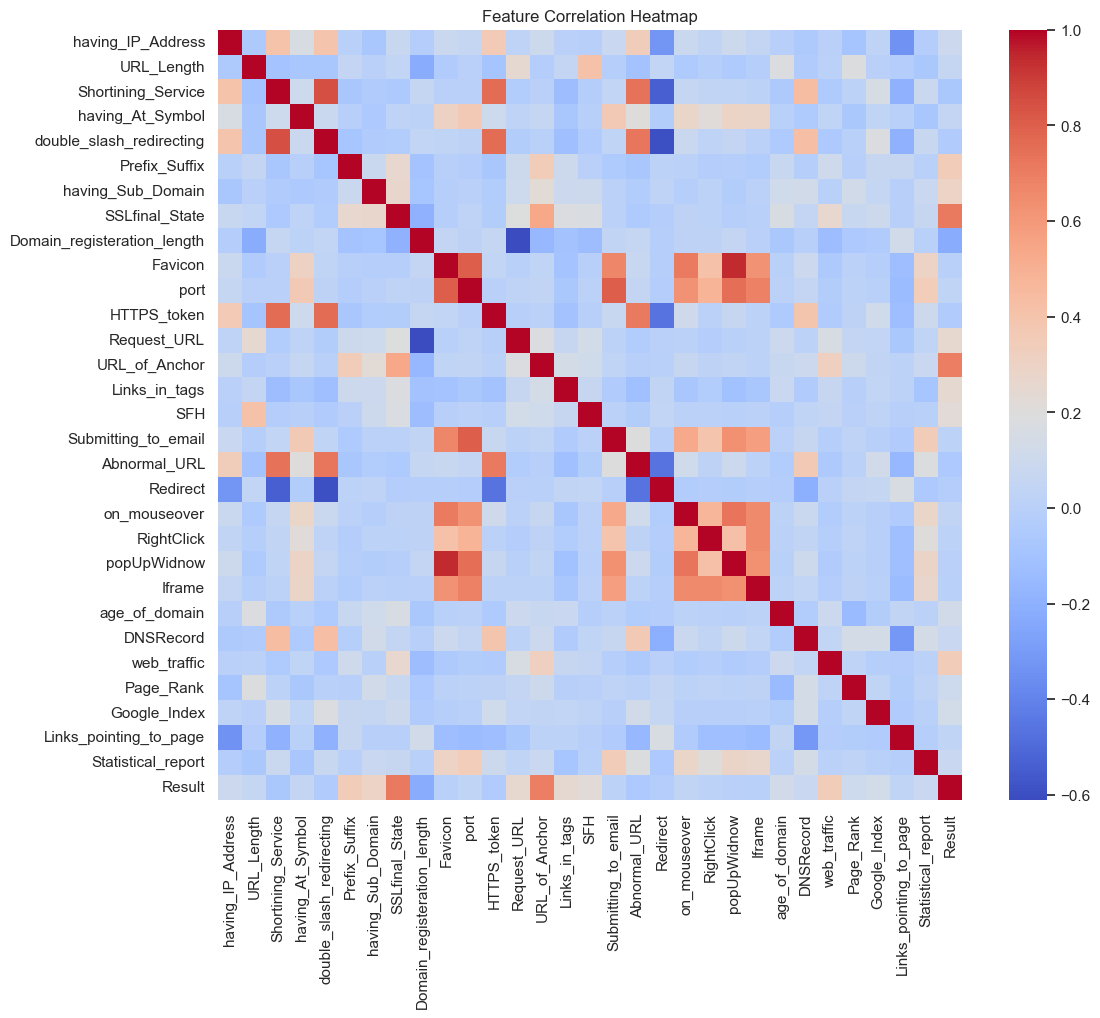

Critical Features:
 Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
Domain_registeration_length    0.225789
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
Name: Result, dtype: float64


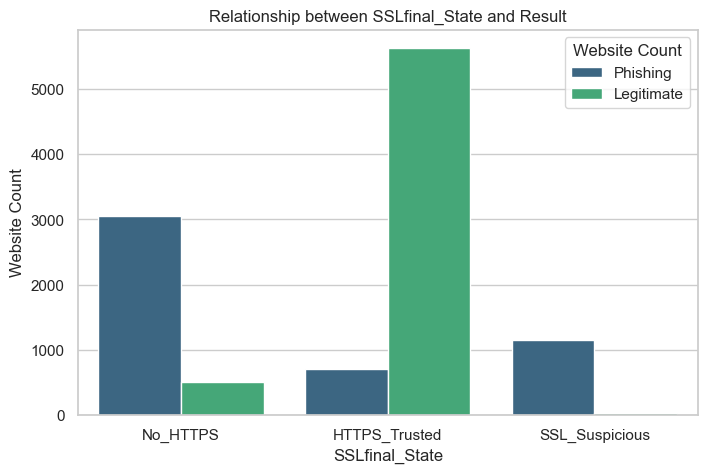

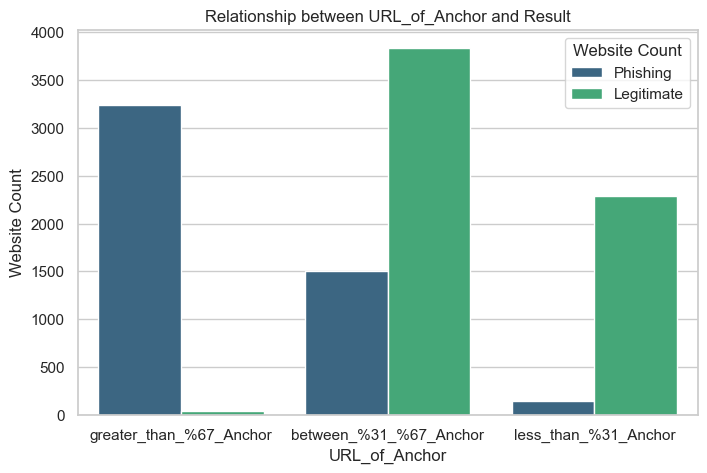

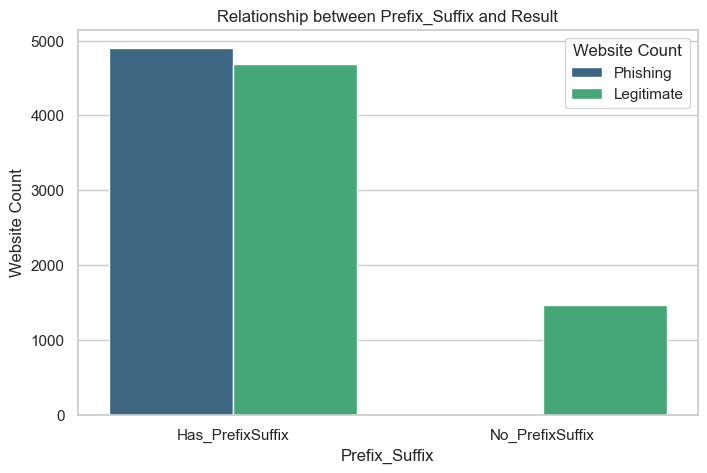

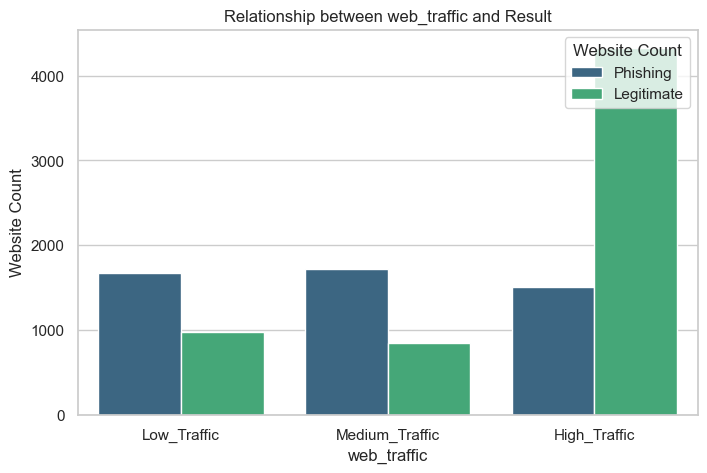

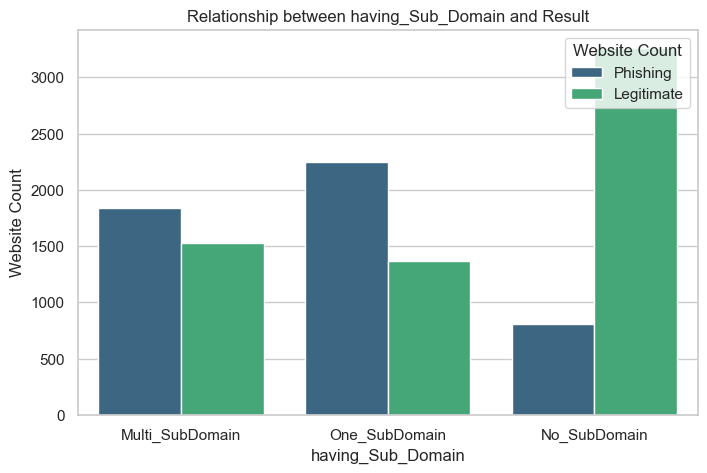

In [27]:
print(df_mapped.info())

for col in df_mapped.columns:
    print(f"--- {col} ---")
    print(df_mapped[col].value_counts())

plt.figure(figsize=(5,5))
pie_chart_colors=['#b8dda9',"#d6857f"]
df_mapped['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=pie_chart_colors)
plt.title('Distribution of Phishing and Legitimate Websites')
plt.ylabel('')
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

top_15_features = df.corr()['Result'].abs().sort_values(ascending=False).head(16)
feature_names = top_15_features.index[1:6]
print("Critical Features:\n", top_15_features)

for col_name in feature_names:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col_name, hue='Result', data=df_mapped, palette='viridis')
    plt.title(f'Relationship between {col_name} and Result')
    plt.xlabel(col_name)
    plt.ylabel('Website Count')
    plt.legend(title='Website Count', loc='upper right')
    plt.show()

The Apriori algorithm was applied using a minimum support of 0.15. Since using all features caused memory errors, only the top 15 features with the highest correlation to the 'Result' column were included in the mining process. Association rules were then generated with a minimum confidence of 0.60. These thresholds were chosen because higher values yielded very few or no results, preventing a comprehensive analysis of the dataset.

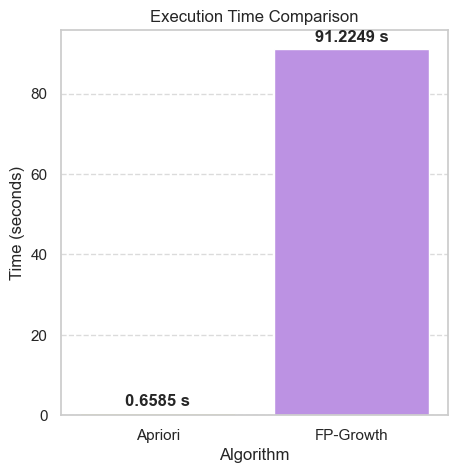

In [28]:
top_15_feature_names = top_15_features.index.tolist()
df_mining = df_mapped[top_15_feature_names]
#print(df_mining)
df_rules = pd.get_dummies(df_mining)
#print(df_rules)

start_time = time.time()
frequent_itemsets = apriori(df_rules, min_support=0.15, use_colnames=True)
apriori_time = time.time() - start_time

start_time_1 = time.time()
frequent_itemsets_fp = fpgrowth(df_rules, min_support=0.15, use_colnames=True)
fp_time = time.time() - start_time_1

algorithms = ['Apriori', 'FP-Growth']
execution_times = [apriori_time, fp_time]

plt.figure(figsize=(5, 5))
colors = ["#FBFD84", "#BC85F0"]
sns.barplot(x=algorithms, y=execution_times, hue=algorithms, palette=colors, legend=False)

for i, time_val in enumerate(execution_times):
    plt.text(i, time_val + (max(execution_times) * 0.01), 
             f'{time_val:.4f} s', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Execution Time Comparison')
plt.ylabel('Time (seconds)')
plt.xlabel('Algorithm')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

GENERATING RULES FOR APRIORI ITEMSETS

In [29]:
def calculate_chi_square_value(row, total_n):
    #(Observed)
    o11 = row['support'] * total_n                         
    o10 = (row['antecedent support'] - row['support']) * total_n 
    o01 = (row['consequent support'] - row['support']) * total_n  
    o00 = total_n - (o11 + o10 + o01)                   

    sum_row1 = o11 + o10  
    sum_row0 = o01 + o00  
    sum_col1 = o11 + o01  
    sum_col0 = o10 + o00 

    # Expected
    e11 = (sum_row1 * sum_col1) / total_n
    e10 = (sum_row1 * sum_col0) / total_n
    e01 = (sum_row0 * sum_col1) / total_n
    e00 = (sum_row0 * sum_col0) / total_n

    #Chi-Square
    chi_sq = (
        ((o11 - e11)**2 / (e11 + 1e-6)) +
        ((o10 - e10)**2 / (e10 + 1e-6)) +
        ((o01 - e01)**2 / (e01 + 1e-6)) +
        ((o00 - e00)**2 / (e00 + 1e-6))
    )
    
    return chi_sq

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.60)
rules['cosine'] = rules['support'] / np.sqrt(rules['antecedent support'] * rules['consequent support'])
rules['all_confidence'] = rules['support'] / rules[['antecedent support', 'consequent support']].max(axis=1)
rules['max_confidence'] = np.maximum( rules['support'] / rules['antecedent support'], rules['support'] / rules['consequent support'] )
rules['chi_square_score'] = rules.apply(lambda row: calculate_chi_square_value(row, len(df_rules)), axis=1)

In [30]:
phishing_rules = rules[rules['consequents'] == frozenset({'Result_Phishing'})]
phishing_rules_sorted = phishing_rules.sort_values(by='lift', ascending=False)
phishing_rules_sorted.to_csv("phishing_specific_rules_minsup_0.15_minconf_0.6.csv", index=False, encoding="utf-8")

legitimate_rules = rules[rules['consequents'] == frozenset({'Result_Legitimate'})]
legitimate_rules_sorted = legitimate_rules.sort_values(by='lift', ascending=False)
legitimate_rules_sorted.to_csv("legitimate_specific_rules_minsup_0.15_minconf_0.6.csv", index=False, encoding="utf-8")

This time, the analysis was run using the entire dataset with FPGrowth. As the dataset had 11,055 rows and 70 columns after running the `get_dummies()` function, the algorithm took a very long time to run. Consequently, a maximum length of 4 was selected and applied for FPGrowth

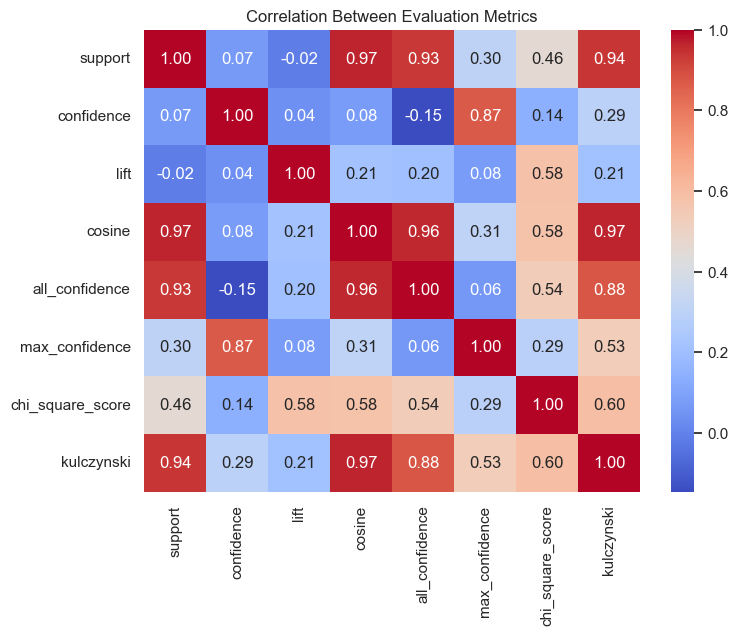

Total Rules Found: 374859
Phishing Specific Rules: 954


In [31]:
df_full_rules = pd.get_dummies(df_mapped)
#print(df_full_rules)
start_time_2 = time.time()
frequent_itemsets_fprowth_with_full_dataset = fpgrowth(df_full_rules, min_support=0.15, use_colnames=True , max_len=4)
fp_time_full_dataset = time.time() - start_time_2

rules_full = association_rules(frequent_itemsets_fprowth_with_full_dataset, metric="confidence", min_threshold=0.60)

rules_full['cosine'] = rules_full['support'] / np.sqrt(rules_full['antecedent support'] * rules_full['consequent support'])
rules_full['all_confidence'] = rules_full['support'] / rules_full[['antecedent support', 'consequent support']].max(axis=1)
rules_full['max_confidence'] = np.maximum( rules_full['support'] / rules_full['antecedent support'], rules_full['support'] / rules_full['consequent support'] )
rules_full['chi_square_score'] = rules_full.apply(lambda row: calculate_chi_square_value(row, len(df_full_rules)), axis=1)

metric_cols = rules_full[['support', 'confidence', 'lift', 'cosine', 'all_confidence', 'max_confidence', 'chi_square_score', 'kulczynski']]
plt.figure(figsize=(8, 6))
sns.heatmap(metric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Evaluation Metrics')
plt.show()

phishing_rules_full = rules_full[rules_full['consequents'] == frozenset({'Result_Phishing'})]
phishing_rules_full_sorted = phishing_rules_full.sort_values(by='lift', ascending=False)
print(f"Total Rules Found: {len(rules_full)}")
print(f"Phishing Specific Rules: {len(phishing_rules_full)}")
phishing_rules_full_sorted.to_csv("full_dataset_phishing_rules.csv", index=False, encoding="utf-8")

Null-Invariance

--- Rule 1 ---
Content: (URL_of_Anchor_greater_than_%67_Anchor, Redirect_Redirect_between_2-4, SSLfinal_State_No_HTTPS) --> Phishing
                Original (N=11k)  Null+ (N=21k)  Difference (%)
Metric                                                         
Lift                      2.2570         4.2987         90.4568
Cosine                    0.6015         0.6015          0.0000
All-Confidence            0.3618         0.3618          0.0000
Max-Confidence            1.0000         1.0000          0.0000
Kulczynski                0.6809         0.6809          0.0000
Chi-Square             2652.6777      6382.4336        140.6034


--- Rule 2 ---
Content: (Prefix_Suffix_Has_PrefixSuffix, URL_of_Anchor_greater_than_%67_Anchor, Links_pointing_to_page_have 1 or 2 links pointing) --> Phishing
                Original (N=11k)  Null+ (N=21k)  Difference (%)
Metric                                                         
Lift                      2.2570         4.2987         90.4568
C

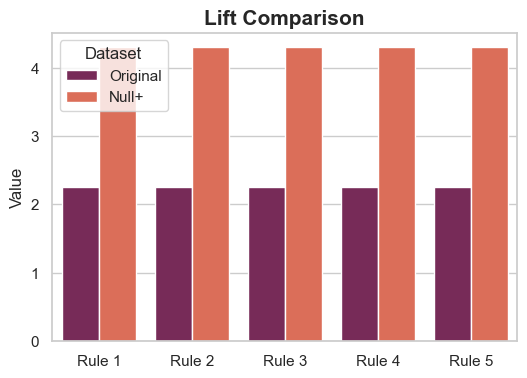

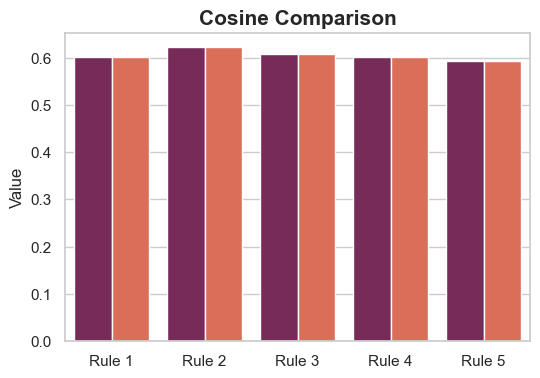

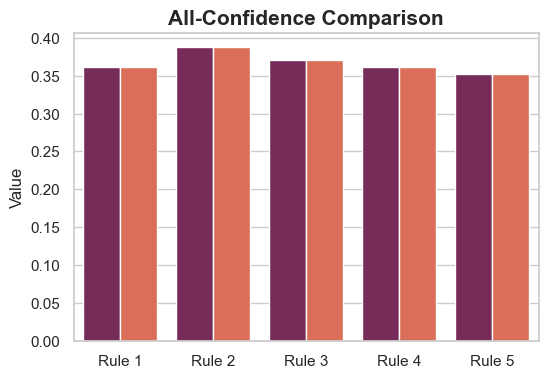

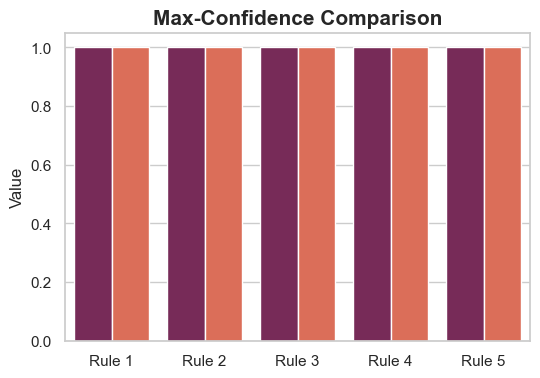

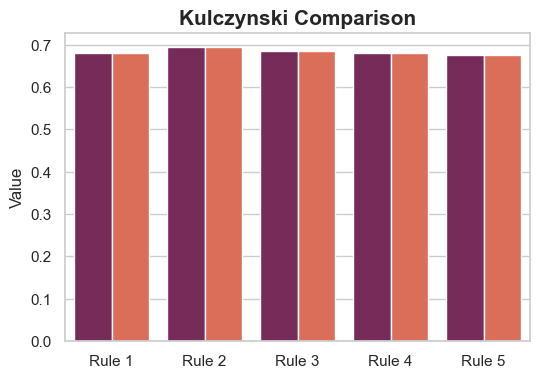

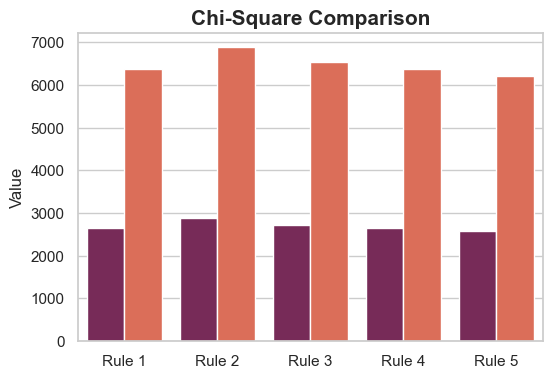

In [ ]:
df_rules_read = pd.read_csv("full_dataset_phishing_rules.csv")
top_5_rules = df_rules_read.head(5).copy()

original_data_size = 11055 
null_data_size = 10000
new_data_size = original_data_size + null_data_size
all_results_for_plot = []

def calculate_metrics(s_a, s_b, s_ab):
        lift = s_ab / (s_a * s_b)
        cosine = s_ab / np.sqrt(s_a * s_b)
        all_conf = s_ab / max(s_a, s_b)
        max_conf = max(s_ab / s_a, s_ab / s_b) 
        kulc = 0.5 * ((s_ab / s_a) + (s_ab / s_b))
        return lift, cosine, all_conf, kulc, max_conf

for i, (idx, rule) in enumerate(top_5_rules.iterrows()):
    clean_ant = str(rule['antecedents']).replace("frozenset({", "").replace("})", "").replace("'", "")
    rule_id_label = f"Rule {i+1}"
    full_rule_name = f"({clean_ant}) --> Phishing"

    support_a_original = rule['antecedent support']
    support_b_original = rule['consequent support']
    support_ab_original = rule['support']
    lift_o, cos_o, all_o, kulc_o, max_o = calculate_metrics(support_a_original, support_b_original, support_ab_original)
    row_orig = pd.Series({'support': support_ab_original, 'antecedent support': support_a_original, 'consequent support': support_b_original})
    chi_o = calculate_chi_square_value(row_orig, original_data_size)

    support_a_new = (support_a_original * original_data_size) / new_data_size
    support_b_new = (support_b_original * original_data_size) / new_data_size
    support_ab_new = (support_ab_original * original_data_size) / new_data_size
    lift_n, cos_n, all_n, kulc_n, max_n = calculate_metrics(support_a_new, support_b_new, support_ab_new)
    row_new = pd.Series({'support': support_ab_new, 'antecedent support': support_a_new, 'consequent support': support_b_new})
    chi_n = calculate_chi_square_value(row_new, new_data_size)

    data = {
        'Metric': ['Lift', 'Cosine', 'All-Confidence','Max-Confidence' ,'Kulczynski', 'Chi-Square'],
        'Original (N=11k)': [lift_o, cos_o, all_o,max_o, kulc_o, chi_o],
        'Null+ (N=21k)': [lift_n, cos_n, all_n,max_n, kulc_n, chi_n]
    }
    rule_table = pd.DataFrame(data).set_index('Metric')
    rule_table['Difference (%)'] = ((rule_table.iloc[:, 1] - rule_table.iloc[:, 0]) / rule_table.iloc[:, 0]) * 100
    
    print(f"--- {rule_id_label} ---")
    print(f"Content: {full_rule_name}")
    print(rule_table.round(4).to_string())
    print("\n" + "="*50 + "\n")

    for m, old_v, new_v in zip(data['Metric'], data['Original (N=11k)'], data['Null+ (N=21k)']):
        all_results_for_plot.append({'Rule': rule_id_label, 'Metric': m, 'Value': old_v, 'Dataset': 'Original'})
        all_results_for_plot.append({'Rule': rule_id_label, 'Metric': m, 'Value': new_v, 'Dataset': 'Null+'})

df_plot = pd.DataFrame(all_results_for_plot)
metrics_list = ['Lift', 'Cosine', 'All-Confidence','Max-Confidence' ,'Kulczynski', 'Chi-Square']

for i, m in enumerate(metrics_list):
    plt.figure(figsize=(6, 4))
    sns.set_theme(style="whitegrid")
    sns.barplot(data=df_plot[df_plot['Metric'] == m], x='Rule', y='Value', hue='Dataset', palette='rocket')
    plt.title(f'{m} Comparison', fontweight='bold', fontsize=15)
    plt.ylabel('Value')
    plt.xlabel('')
    if i != 0: plt.legend([],[], frameon=False)
    plt.show()

In [5]:
df_phishing_subset = pd.read_csv("phishing_specific_rules_minsup_0.15_minconf_0.6.csv")
df_sorted_kulc_subset = df_phishing_subset.sort_values(by='kulczynski', ascending=False)
df_sorted_kulc_subset.to_csv("phishing_subset_sorted_by_kulc.csv", index=False)
print(df_sorted_kulc_subset)

df_phishing_full_dataset = pd.read_csv("full_dataset_phishing_rules.csv")
df_sorted_kulc_full_dataset = df_phishing_full_dataset.sort_values(by='kulczynski', ascending=False)
df_sorted_kulc_full_dataset.to_csv("phishing_full_sorted_by_kulc.csv", index=False)
print(df_sorted_kulc_full_dataset)


                                           antecedents  \
11   frozenset({'Prefix_Suffix_Has_PrefixSuffix', '...   
32   frozenset({'URL_of_Anchor_greater_than_%67_Anc...   
14   frozenset({'Prefix_Suffix_Has_PrefixSuffix', '...   
33   frozenset({'URL_of_Anchor_greater_than_%67_Anc...   
15   frozenset({'Prefix_Suffix_Has_PrefixSuffix', '...   
..                                                 ...   
152  frozenset({'having_Sub_Domain_One_SubDomain', ...   
139             frozenset({'web_traffic_Low_Traffic'})   
150  frozenset({'Prefix_Suffix_Has_PrefixSuffix', '...   
147  frozenset({'DNSRecord_Has_DNS_Record', 'Links_...   
156  frozenset({'Statistical_report_Dont Belong to ...   

                        consequents  antecedent support  consequent support  \
11   frozenset({'Result_Phishing'})            0.295251            0.443057   
32   frozenset({'Result_Phishing'})            0.296879            0.443057   
14   frozenset({'Result_Phishing'})            0.250294           